In [ ]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, restoration, img_as_float, img_as_ubyte
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os
import glob
import cv2
import pandas as pd
import time # to track the execution time
import seaborn as sns

In [2]:
# define the global variable
base_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
BLUR_PATH = os.path.join(base_dir, "..", "data", "blur", "images")
SHARP_PATH = os.path.join(base_dir, "..", "data", "sharp", "images")

### Step 1. Detecting Image Blur Intensity

identify blur intensities for all images, then classified them

In [3]:
# define threshold for blur intensity
low_freq_threshold = 30    # Distance in pixels. Assumption
high_freq_threshold = 100  # Distance in pixels. Assumption

def calculate_blur_intensity(img_path, low_point=30, high_point=100):
    img = cv2.imread(img_path)
    height, width = img.shape[0:2]
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # transform into gray
    fft_2d = np.fft.fft2(img_gray) # implement Fourier Transformation
    fft_shifted = np.fft.fftshift(fft_2d)

    # calculate magnitude
    magnitude_spectrum = np.abs(fft_shifted)
    log_magnitude = np.log1p(magnitude_spectrum)

    # calculate blur score by using radial energy profile
    cy, cx = height // 2, width // 2
    y, x = np.ogrid[:height, : width]
    radial_distance = np.sqrt((x - cx)**2 + (y - cy)**2)

    # Define frequency rings:
    # - Low frequencies: close to center (distance 0-30)
    # - High frequencies: far from center (distance > 100)
    # These thresholds can be tuned based on your images
    
    # Create masks for different frequency regions
    low_freq_mask = radial_distance <= low_point
    high_freq_mask = radial_distance >= high_point
    
    # Sum up energy (magnitude) in each frequency region
    low_freq_energy = np.sum(magnitude_spectrum[low_freq_mask])
    high_freq_energy = np.sum(magnitude_spectrum[high_freq_mask])
    total_energy = np.sum(magnitude_spectrum)

    blur_score = (high_freq_energy / total_energy)* 1000 # using only high frequency energy

    return blur_score


In [4]:
# calculate blur intensities for all blur image
image_extensions = ["*.png", "*.jpg", "*.jpeg"]
blur_paths = []
result_deblur_list = []

# get the blur images path
for e in image_extensions:
    blur_paths.extend(glob.glob(os.path.join(BLUR_PATH, e)))
# print(f"Found blur images:{len(blur_paths)}")

blur_int_list = []
for i in blur_paths:
    blur_score = calculate_blur_intensity(i)
    blur_int_list.append(blur_score) 

blur_int_pair = pd.DataFrame({'blur_paths':blur_paths, 'blur_int':blur_int_list}) # 4 mins

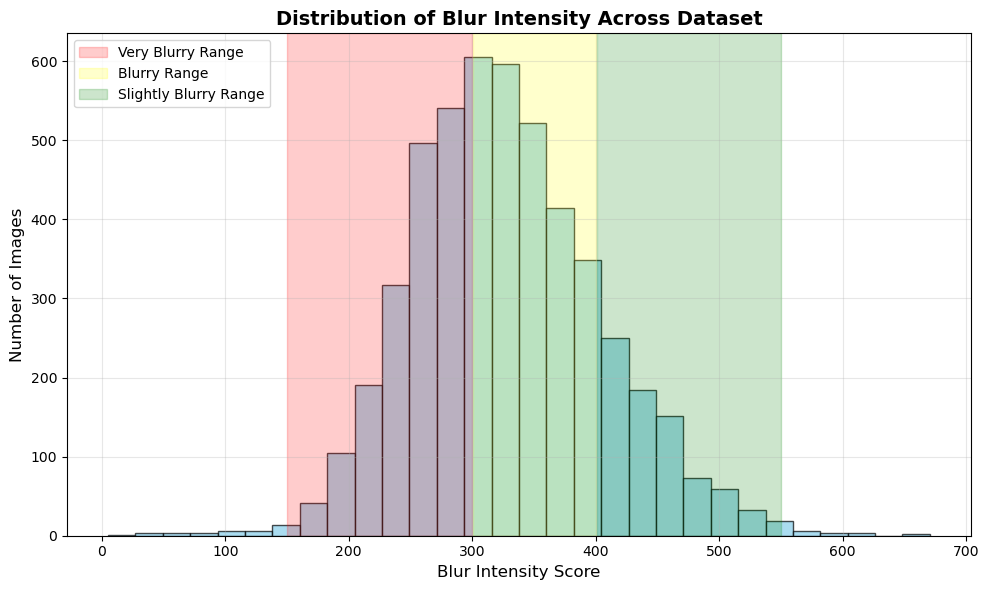

In [5]:
# make script for histogram in matplotlib by using blur_int_pair['blur_int']
plt.figure(figsize=(10, 6))
plt.hist(blur_int_pair['blur_int'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Blur Intensity Score', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Blur Intensity Across Dataset', fontsize=14, fontweight='bold')
plt.axvspan(150,300, alpha=0.2, color='red', label='Very Blurry Range')
plt.axvspan(301,400, alpha=0.2, color='yellow', label='Blurry Range')
plt.axvspan(401,550, alpha=0.2, color='green', label='Slightly Blurry Range')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

From the graphic above, we make 3 categories:
- Blur intensity 150 - 300: very blurry
- Blur intensity 301 - 400: blurry
- Blur intensity > 401: slightly blurry

We take each of the categories 2 images as an example

In [5]:

cat_very_blur = blur_int_pair.nsmallest(n=2, columns=['blur_int']) # very blurry category
cat_very_blur_img = [os.path.basename(path) for path in cat_very_blur['blur_paths']]

cat_blur = blur_int_pair[blur_int_pair['blur_int'].between(350,450)].nsmallest(n=2, columns=['blur_int']) # blur category
cat_blur_img = [os.path.basename(path) for path in cat_blur['blur_paths']]

cat_slight_blur = blur_int_pair[blur_int_pair['blur_int'].between(450,500)].nsmallest(n=2, columns=['blur_int']) # slightly blur category
cat_slight_blur_img = [os.path.basename(path) for path in cat_slight_blur['blur_paths']]

print(f"The images for very blur category: {cat_very_blur_img}.")
print(f"The images for blur category: {cat_blur_img}")
print(f"The images for slightly blur category: {cat_slight_blur_img}")

The images for very blur category: ['000000149770.jpg', '000000456394.jpg'].
The images for blur category: ['000000106563.jpg', '000000337987.jpg']
The images for slightly blur category: ['000000017436.jpg', '000000054123.jpg']


### Step 2. Build and Implement Wiener Filter

Now, we will build and implement deblurring to these 6 images and see the comparison.

First, we will build a Wiener Filter

In [6]:
# define the blur kernesl (PSF))
# PSF: Point Spread Function.
# Kernel size: the size of the PSF kernel
# Sigma: to control the amount of blurring. A larger sigma will result in a blurrier image.
# Using Gaussian kernel as the PSF for Wiener deblurring

def gaussian_kernel(size=15, power=3):
    ax = np.arange(size) - size // 2
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * power**2))
    return kernel / kernel.sum()


In [7]:
# Build wiener filter function
def wiener_filter(blur_img, psf, wiener_balance = 0.15): 
    deblurred_channel = []
    for ch in range(3):
        restored_ch = restoration.wiener(blur_img[:,:,ch], psf, balance=wiener_balance) # perform it on every channel
        deblurred_channel.append(restored_ch)
    
    deblurred = np.stack(deblurred_channel, axis=-1)
    deblurred = np.clip(deblurred, 0, 1)

    return deblurred

In [8]:
# Build function to implement PSF and wiener filter
kernel_size = 15 # assumption
sigma = 3 # assumption
wiener_balance = 0.15 # assumption

def deblur_wiener(blur_img, size=15, power=3, balance=0.15):
    # get the image
    blurred_raw = io.imread(blur_img) # to convert the image to a floating-point representation in the range [0, 1]
    blurred = img_as_float(blurred_raw) # to convert the image back to an unsigned 8-bit integer format (0-255)

    # call gaussian kernel
    psf = gaussian_kernel(size=size, power=power) # make gaussian kernel
    # call wiener filter
    result = wiener_filter(blurred, psf,wiener_balance=balance)

    return result # the result shape is 720x1280x3


C:\Users\qunto\AppData\Local\Temp\ipykernel_39596\1165706109.py:35: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  blur_int_val = float(blur_int_data[blur_int_data['blur_paths'] == img_path]['blur_int'])


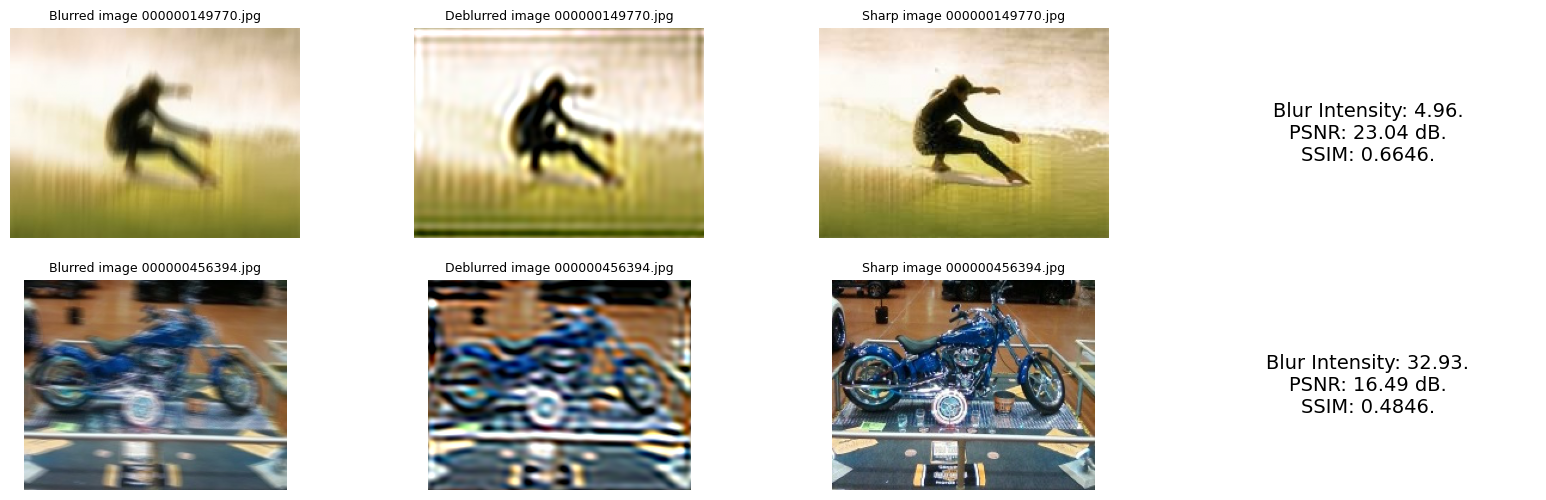

In [9]:
# Build function to call the wiener filter, calculate PSNR and SSIM, and plot them. Use it on each of categories.

def compare_and_plot(target_images, blur_int_data,size=15, power=3, balance=0.15):
    """
    blur_int_data: dataframe from list of 

    """
    # 1. get the blurred image
    blurred_list = []
    for i in target_images:        
        address_blur = os.path.join(BLUR_PATH,i) # get address of all images
        blurred_raw = io.imread(address_blur) # to convert the image to a floating-point representation in the range [0, 1]
        blurred = img_as_float(blurred_raw) # to convert the image back to an unsigned 8-bit integer format (0-255)
        blurred_list.append(blurred)
    
    # 2. implement deblur process using wiener filter
    deblur_result_list = []
    for i in target_images:
        img_path = os.path.join(BLUR_PATH,i)
        deblur_img = deblur_wiener(img_path, size=size, power=power, balance=balance)
        deblur_result_list.append(deblur_img)
    
    # 3. get the sharp images
    sharp_list = []
    for i in target_images:
        address_sharp = os.path.join(SHARP_PATH,i)
        sharp_raw = io.imread(address_sharp) # to convert the image to a floating-point representation in the range [0, 1]
        sharp = img_as_float(sharp_raw) # to convert the image back to an unsigned 8-bit integer format (0-255)
        sharp_list.append(sharp)

    # 5. get the blur intensity and calculate the psnr and ssim
    blur_psnr_ssim_val = []
    for i in range(len(target_images)):
        img_path = os.path.join(BLUR_PATH,target_images[i])
        blur_int_val = float(blur_int_data[blur_int_data['blur_paths'] == img_path]['blur_int'])
        psnr_val = psnr(deblur_result_list[i], sharp_list[i], data_range=1.0)
        ssim_val = ssim(deblur_result_list[i], sharp_list[i], channel_axis=2, data_range=1.0)
        res_blur_psnr_ssim = f"Blur Intensity: {blur_int_val:.2f}.\nPSNR: {psnr_val:.2f} dB.\nSSIM: {ssim_val:.4f}."
        blur_psnr_ssim_val.append(res_blur_psnr_ssim)

    # 6. plot all of the data
    fig, axes = plt.subplots(len(target_images), 4, figsize=(len(target_images)*10, len(target_images)*3), squeeze=False)
    for x in range(len(target_images)):
        # show the images of blurred, deblurre, and sharp
        axes[x][0].imshow(blurred_list[x])
        axes[x][1].imshow(deblur_result_list[x])
        axes[x][2].imshow(sharp_list[x])    
        axes[x][3].text(0.5, 0.5, blur_psnr_ssim_val[x], transform=axes[x, 3].transAxes,
                ha='center', va='center', fontsize=14, color='black')
        
        # show the title
        axes[x][0].set_title(f"Blurred image {target_images[x]}", fontsize=9)
        axes[x][1].set_title(f"Deblurred image {target_images[x]}", fontsize=9)
        axes[x][2].set_title(f"Sharp image {target_images[x]}", fontsize=9)

        # set off the axis
        axes[x][0].axis("off")
        axes[x][1].axis("off")
        axes[x][2].axis("off")
        axes[x][3].axis("off")

    plt.show()

# compare and plot for very blurry category
compare_and_plot(cat_very_blur_img, blur_int_pair)

C:\Users\qunto\AppData\Local\Temp\ipykernel_30128\1165706109.py:35: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  blur_int_val = float(blur_int_data[blur_int_data['blur_paths'] == img_path]['blur_int'])


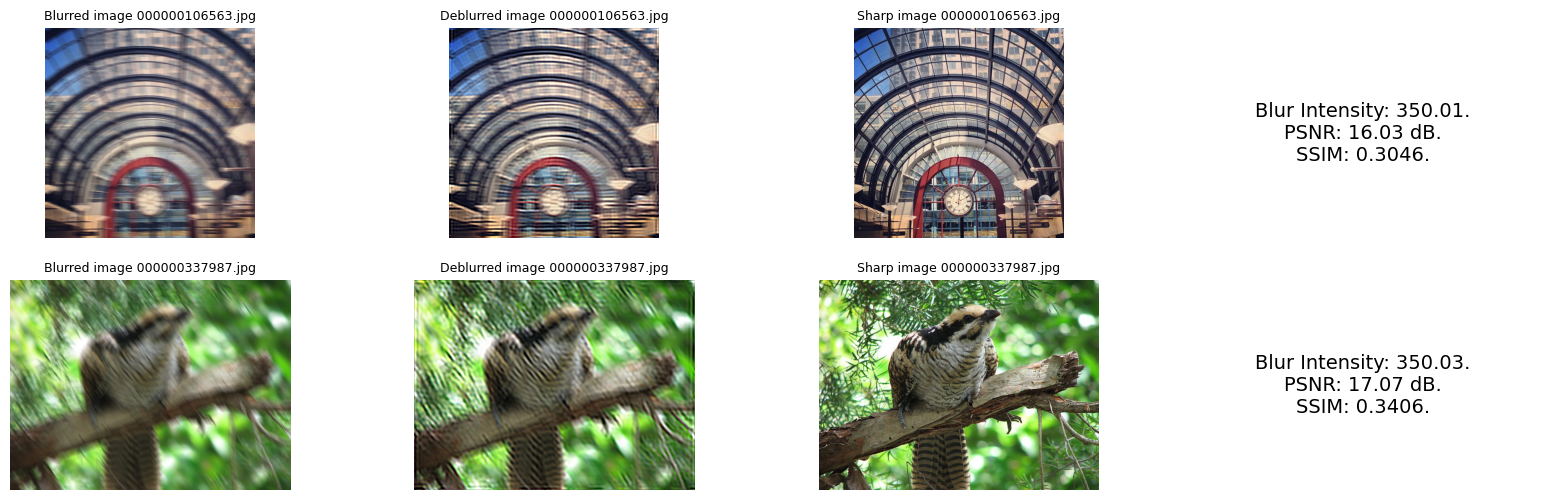

In [12]:
# compare and plot for blurry category
compare_and_plot(cat_blur_img, blur_int_pair)

C:\Users\qunto\AppData\Local\Temp\ipykernel_30128\1165706109.py:35: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  blur_int_val = float(blur_int_data[blur_int_data['blur_paths'] == img_path]['blur_int'])


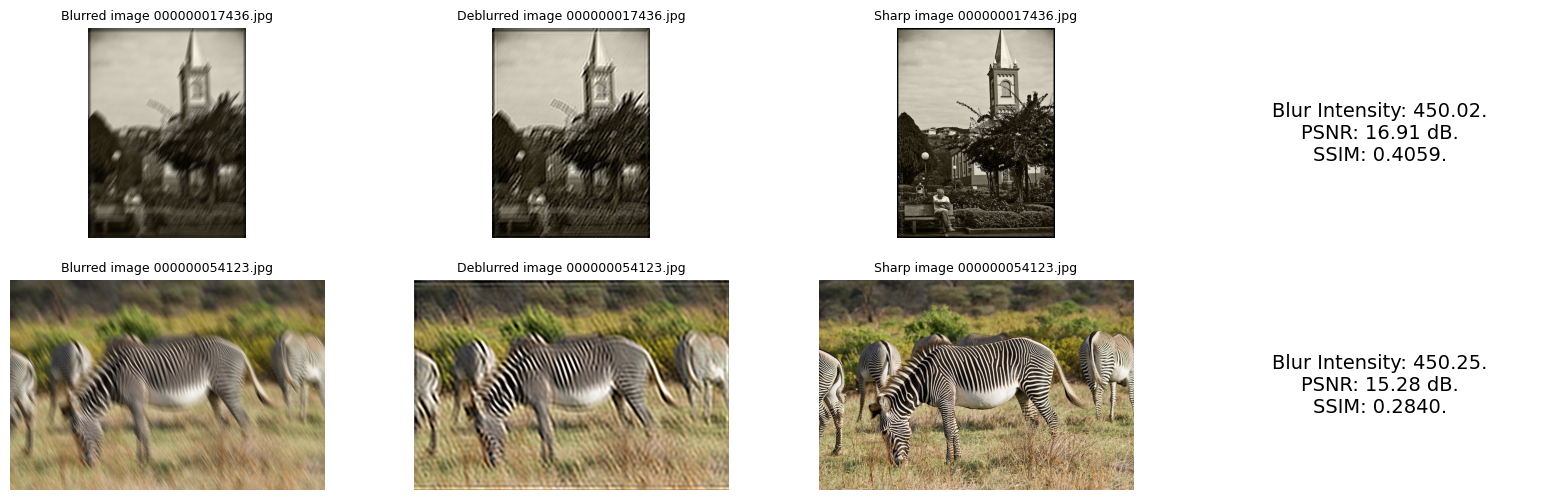

In [14]:
# compare and plot for slightly blurry category
compare_and_plot(cat_slight_blur_img, blur_int_pair)

Make conclusion about the deblur process

abcdef

### Step 3. Implement all Wiener Filter deblurring to all images and store the new image

In [15]:
# function to deblur all blurred images and store it to a new folder
def deblur_wiener_and_store(blur_path, size=15, power=3, balance=0.15):
    """
    """
    image_extensions = ["*.png", "*.jpg", "*.jpeg"]
    blur_paths = []

    # Define the output folder path
    output_folder = os.path.join(base_dir, "..", "data", "deblur_wiener", "images") # change this accordingly

    # Check if folder exists, create it if it doesn't
    # os.makedirs(output_folder, exist_ok=True)

    # Remove the folder if it exists, then create a fresh one
    if os.path.exists(output_folder):
        for filename in os.listdir(output_folder):
            file_path = os.path.join(output_folder, filename)
            if os.path.isfile(file_path):
                os.unlink(file_path)
    else:
        os.makedirs(output_folder, exist_ok=True)

    # get the blur images path
    for e in image_extensions:
        blur_paths.extend(glob.glob(os.path.join(blur_path, e)))
    # print(f"Found blur images:{len(blur_paths)}")

    # perform deblur process using wiener filter and save it to designated  folder
    for i in blur_paths:
        deblur_img = deblur_wiener(i, size=size, power=power, balance=balance)
        # Construct the full file path for saving
        output_path = os.path.join(output_folder, os.path.basename(i))

        # Convert deblurred image to 8-bit format and save
        deblur_img_uint8 = img_as_ubyte(deblur_img)
        io.imsave(output_path, deblur_img_uint8)
    
    print(f"Successully deblur {len(blur_paths)} images!")        

In [17]:
# Before calling the function
start_time = time.perf_counter()

deblur_wiener_and_store(BLUR_PATH, size=15, power=3, balance=0.15)

# After the function completes
end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Total execution time: {elapsed_time/60:.2f} minutes.")
print(f"Total execution time: {elapsed_time:.2f} seconds.")


c:\ProgramData\anaconda3\envs\huggingface\lib\site-packages\skimage\_shared\utils.py:328: UserWarning: d:\MSC AIML - Adelaide\!-COURSES-!\7- COMPUTER VISION AND MULTIMODAL ML\Assignment\Assignment 1\notebooks\..\data\deblur_wiener\images\000000496409.jpg is a low contrast image
  return func(*args, **kwargs)


Successully deblur 5000 images!
Total execution time: 10.64 minutes.
Total execution time: 638.39 seconds.


### Step 4 - Analysis

In [ ]:
# the script is to calculate PSNR and SSIM of the blur and sharp image
# Initialize lists to store data for blur vs sharp comparison
blur_vs_sharp_data = []

# Get all blurred image paths
image_extensions = ["*.png", "*.jpg", "*.jpeg"]
all_blur_paths = []
for e in image_extensions:
    all_blur_paths.extend(glob.glob(os.path.join(BLUR_PATH, e)))

print(f"Processing {len(all_blur_paths)} images for Blur vs Sharp comparison...")

for blur_img_path in all_blur_paths:
    image_name = os.path.basename(blur_img_path)

    # Read blurred image
    blurred_raw = io.imread(blur_img_path)
    blurred_img = img_as_float(blurred_raw)
    # Ensure blurred image is 3-channel (RGB) if it was grayscale
    if blurred_img.ndim == 2:
        blurred_img = color.gray2rgb(blurred_img)

    # Read corresponding sharp image
    sharp_img_path = os.path.join(SHARP_PATH, image_name) # Define sharp_img_path here
    sharp_raw = io.imread(sharp_img_path)
    sharp_img = img_as_float(sharp_raw)
    # Ensure sharp image is 3-channel (RGB) if it was grayscale
    if sharp_img.ndim == 2:
        sharp_img = color.gray2rgb(sharp_img)

    # Check if image dimensions match (height, width, and channels), and resize blurred_img if they don't
    if blurred_img.shape != sharp_img.shape:
        # print(f"Warning: Image {image_name} has mismatched dimensions. Resizing blurred image.")
        # cv2.resize expects (width, height) tuple for dsize
        # For a 3-channel image, cv2.resize handles all channels
        blurred_img_resized = cv2.resize(blurred_img,
                                         (sharp_img.shape[1], sharp_img.shape[0]),
                                         interpolation=cv2.INTER_AREA)
        blurred_img = blurred_img_resized

    # Get blur intensity
    blur_intensity_val = float(blur_int_pair[blur_int_pair['blur_paths'] == blur_img_path]['blur_int'].iloc[0])

    # Calculate PSNR and SSIM for blur vs sharp
    # data_range should be 1.0 since images are img_as_float (0-1 range)
    psnr_blur = psnr(blurred_img, sharp_img, data_range=1.0)
    ssim_blur = ssim(blurred_img, sharp_img, channel_axis=2, data_range=1.0)

    blur_vs_sharp_data.append({
        'image_name': image_name,
        'blur_intensity': blur_intensity_val,
        'PSNR_value': psnr_blur,
        'SSIM_value': ssim_blur
    })

df_blur_vs_sharp = pd.DataFrame(blur_vs_sharp_data)

display(df_blur_vs_sharp.head()) # 17 mins

Processing 5000 images for Blur vs Sharp comparison...


,image_name,blur_intensity,PSNR_value,SSIM_value
0,000000000139.jpg,329.503005,24.978897,0.742013
1,000000000285.jpg,478.501930,22.482049,0.614832
2,000000000632.jpg,396.378689,20.636651,0.500358
3,000000000724.jpg,293.157470,21.646252,0.642676
4,000000000776.jpg,504.609850,23.241709,0.542499


In [19]:
def calculate_deblur_metrics(blur_path, blur_int_data, size=15, power=3, balance=0.15):
    """
    Applies Wiener deblurring to all images in a specified blur_path,
    and calculates PSNR and SSIM against corresponding sharp images.

    Args:
        blur_path (str): Path to the folder containing blurred images.
        blur_int_data (pd.DataFrame): DataFrame containing blur intensities for images.
        size (int): Size of the Gaussian kernel (PSF).
        power (int): Sigma value for the Gaussian kernel, controlling blur amount.
        balance (float): Wiener filter balance parameter.

    Returns:
        pd.DataFrame: A DataFrame with 'image_name', 'blur_intensity', 'PSNR_value', and 'SSIM_value' columns.
    """
    deblur_metrics_data = []
    image_extensions = ["*.png", "*.jpg", "*.jpeg"]
    all_blur_paths = []

    for e in image_extensions:
        all_blur_paths.extend(glob.glob(os.path.join(blur_path, e)))

    print(f"Processing {len(all_blur_paths)} images for Deblur (Wiener) vs Sharp comparison...")

    for current_blur_img_path in all_blur_paths:
        image_name = os.path.basename(current_blur_img_path)

        # Implement deblur process using wiener filter directly
        deblurred_img = deblur_wiener(current_blur_img_path, size=size, power=power, balance=balance)

        # Read corresponding sharp image
        sharp_img_path = os.path.join(SHARP_PATH, image_name)
        try:
            sharp_raw = io.imread(sharp_img_path)
            sharp_img = img_as_float(sharp_raw)
            if sharp_img.ndim == 2:
                sharp_img = color.gray2rgb(sharp_img)
        except FileNotFoundError:
            print(f"Warning: Sharp image {image_name} not found. Skipping.")
            continue

        # Check if image dimensions match (height, width, and channels), and resize deblurred_img if they don't
        if deblurred_img.shape != sharp_img.shape:
            deblurred_img = cv2.resize(deblurred_img,
                                           (sharp_img.shape[1], sharp_img.shape[0]),
                                           interpolation=cv2.INTER_AREA)

        # Get blur intensity
        blur_intensity_val = float(blur_int_data[blur_int_data['blur_paths'] == current_blur_img_path]['blur_int'].iloc[0])

        # Calculate PSNR and SSIM for deblur_wiener vs sharp
        psnr_deblur = psnr(deblurred_img, sharp_img, data_range=1.0)
        ssim_deblur = ssim(deblurred_img, sharp_img, channel_axis=2, data_range=1.0)

        deblur_metrics_data.append({
            'image_name': image_name,
            'blur_intensity': blur_intensity_val,
            'PSNR_value': psnr_deblur,
            'SSIM_value': ssim_deblur
        })

    return pd.DataFrame(deblur_metrics_data)

# Call the new function to generate the DataFrame
df_deblur_vs_sharp = calculate_deblur_metrics(BLUR_PATH, blur_int_pair, 15, 3, 0.15)
display(df_deblur_vs_sharp.head())

Processing 5000 images for Deblur (Wiener) vs Sharp comparison...


,image_name,blur_intensity,PSNR_value,SSIM_value
0,000000000139.jpg,329.503005,22.900139,0.624802
1,000000000285.jpg,478.501930,20.138652,0.523399
2,000000000632.jpg,396.378689,19.418770,0.408418
3,000000000724.jpg,293.157470,19.966312,0.554722
4,000000000776.jpg,504.609850,20.999139,0.432154


In [20]:
# Calculate average PSNR and SSIM for blur vs sharp
avg_psnr_blur = df_blur_vs_sharp['PSNR_value'].mean()
avg_ssim_blur = df_blur_vs_sharp['SSIM_value'].mean()

# Calculate average PSNR and SSIM for deblur_wiener vs sharp
avg_psnr_deblur = df_deblur_vs_sharp['PSNR_value'].mean()
avg_ssim_deblur = df_deblur_vs_sharp['SSIM_value'].mean()

print(f"--- Average Metrics: Blur vs Sharp ---")
print(f"Average PSNR (Blur vs Sharp): {avg_psnr_blur:.2f} dB")
print(f"Average SSIM (Blur vs Sharp): {avg_ssim_blur:.4f}")
print(f"\n--- Average Metrics: Deblur (Wiener) vs Sharp ---")
print(f"Average PSNR (Deblur vs Sharp): {avg_psnr_deblur:.2f} dB")
print(f"Average SSIM (Deblur vs Sharp): {avg_ssim_deblur:.4f}")

--- Average Metrics: Blur vs Sharp ---
Average PSNR (Blur vs Sharp): 22.48 dB
Average SSIM (Blur vs Sharp): 0.6068

--- Average Metrics: Deblur (Wiener) vs Sharp ---
Average PSNR (Deblur vs Sharp): 21.18 dB
Average SSIM (Deblur vs Sharp): 0.5336


In [ ]:
# Function to categorize blur intensity

def categorize_blur(intensity):
    if intensity <= 300:
        return 'Very Blurry'
    elif intensity <= 400:  # 300 - 400
        return 'Blurry'
    else:  # above 400
        return 'Slightly Blurry'

# Apply the categorization to both DataFrames
df_blur_vs_sharp['blur_category'] = df_blur_vs_sharp['blur_intensity'].apply(categorize_blur)
df_deblur_vs_sharp['blur_category'] = df_deblur_vs_sharp['blur_intensity'].apply(categorize_blur)

display(df_blur_vs_sharp.head())
display(df_deblur_vs_sharp.head())


,image_name,blur_intensity,PSNR_value,SSIM_value,blur_category
0,000000000139.jpg,329.503005,24.978897,0.742013,Blurry
1,000000000285.jpg,478.501930,22.482049,0.614832,Slightly Blurry
2,000000000632.jpg,396.378689,20.636651,0.500358,Blurry
3,000000000724.jpg,293.157470,21.646252,0.642676,Very Blurry
4,000000000776.jpg,504.609850,23.241709,0.542499,Slightly Blurry


,image_name,blur_intensity,PSNR_value,SSIM_value,blur_category
0,000000000139.jpg,329.503005,22.900139,0.624802,Blurry
1,000000000285.jpg,478.501930,20.138652,0.523399,Slightly Blurry
2,000000000632.jpg,396.378689,19.418770,0.408418,Blurry
3,000000000724.jpg,293.157470,19.966312,0.554722,Very Blurry
4,000000000776.jpg,504.609850,20.999139,0.432154,Slightly Blurry


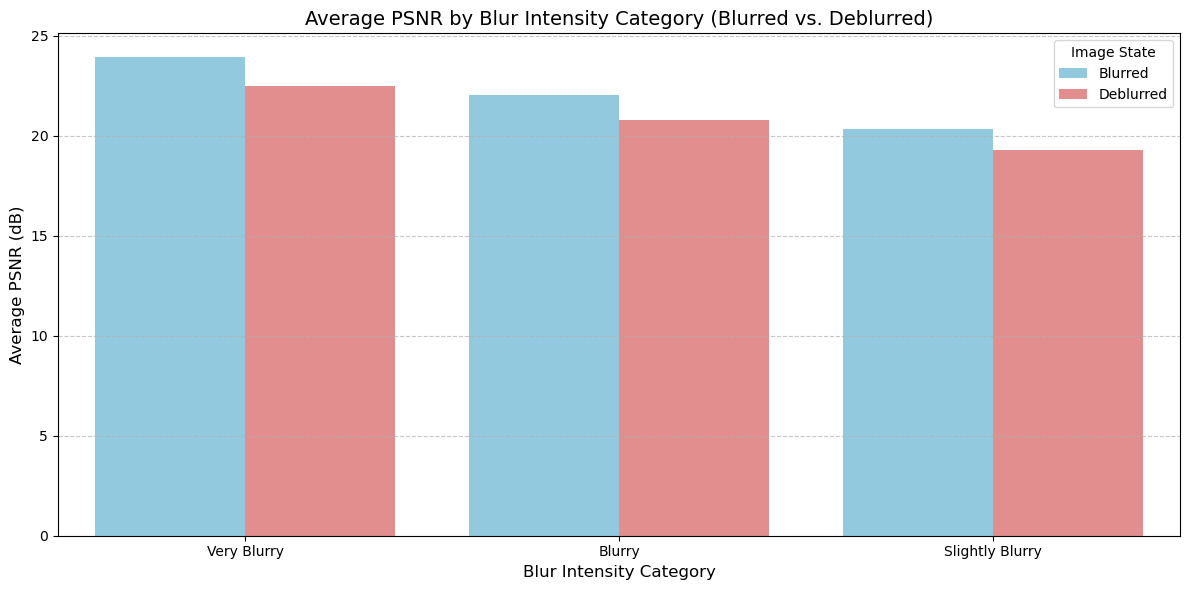

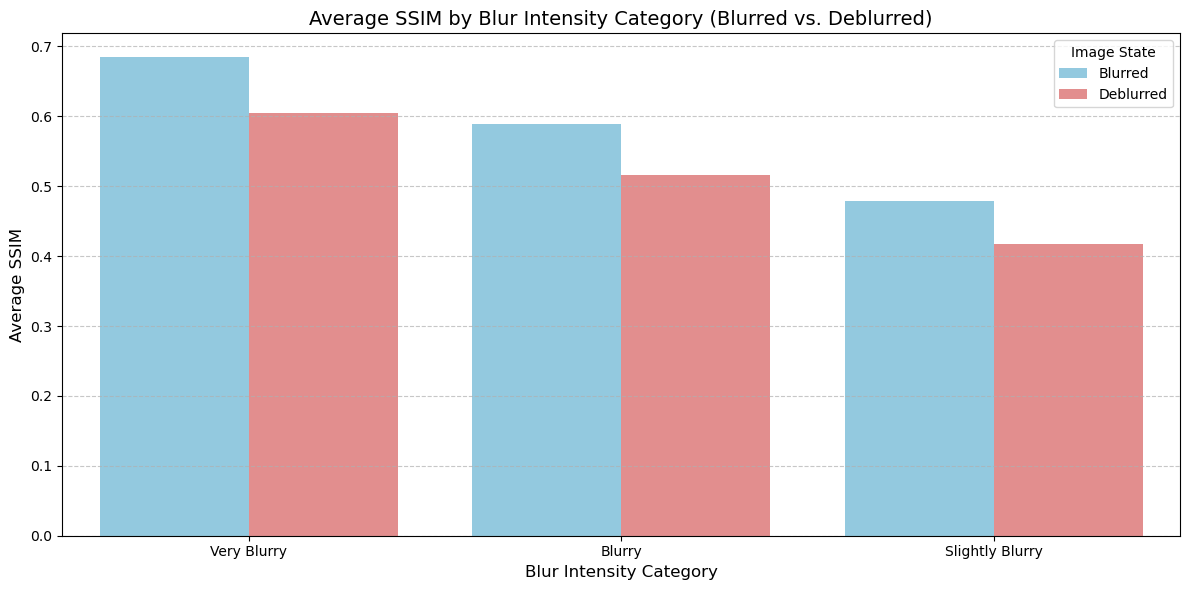

In [23]:
import seaborn as sns

# Group by blur category and calculate mean PSNR and SSIM for blur vs sharp
summary_blur = df_blur_vs_sharp.groupby('blur_category')[['PSNR_value', 'SSIM_value']].mean().reset_index()
summary_blur['Comparison'] = 'Blurred'

# Group by blur category and calculate mean PSNR and SSIM for deblur vs sharp
summary_deblur = df_deblur_vs_sharp.groupby('blur_category')[['PSNR_value', 'SSIM_value']].mean().reset_index()
summary_deblur['Comparison'] = 'Deblurred'

# Combine the summaries for plotting, resetting the index to avoid duplicates
combined_summary = pd.concat([summary_blur, summary_deblur], ignore_index=True)

# Define a consistent order for blur categories, including 'Other'
category_order = ['Very Blurry', 'Blurry', 'Slightly Blurry']
combined_summary['blur_category'] = pd.Categorical(combined_summary['blur_category'], categories=category_order, ordered=True)
combined_summary = combined_summary.sort_values('blur_category')


# Plotting PSNR
plt.figure(figsize=(12, 6))
sns.barplot(x='blur_category', y='PSNR_value', hue='Comparison', data=combined_summary, palette={'Blurred': 'skyblue', 'Deblurred': 'lightcoral'})
plt.title('Average PSNR by Blur Intensity Category (Blurred vs. Deblurred)', fontsize=14)
plt.xlabel('Blur Intensity Category', fontsize=12)
plt.ylabel('Average PSNR (dB)', fontsize=12)
plt.legend(title='Image State')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting SSIM
plt.figure(figsize=(12, 6))
sns.barplot(x='blur_category', y='SSIM_value', hue='Comparison', data=combined_summary, palette={'Blurred': 'skyblue', 'Deblurred': 'lightcoral'})
plt.title('Average SSIM by Blur Intensity Category (Blurred vs. Deblurred)', fontsize=14)
plt.xlabel('Blur Intensity Category', fontsize=12)
plt.ylabel('Average SSIM', fontsize=12)
plt.legend(title='Image State')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [11]:
def analyse_deblurring_metrics(blur_input_path, sharp_input_path, size=15, power=3, balance=0.15):
    """
    Applies Wiener deblurring to all images in a specified folder, and calculates
    PSNR and SSIM against the sharp images.
    """
    metrics_data = []
    image_extensions = ["*.png", "*.jpg", "*.jpeg"]
    all_blur_paths = []

    for e in image_extensions:
        all_blur_paths.extend(glob.glob(os.path.join(blur_input_path, e)))

    print(f"Analysing deblurring metrics for {len(all_blur_paths)} images...")

    for blur_img_path in all_blur_paths:
        image_name = os.path.basename(blur_img_path)

        # 1. Generate deblurred image using deblur_wiener function
        try:
            # deblur_wiener returns a float image array (0-1 range) with 3 channels
            deblurred_img = deblur_wiener(blur_img_path, size=size, power=power, balance=balance)
        except Exception as e:
            print(f"Error deblurring {image_name}: {e}. Skipping.")
            continue

        # 2. Read corresponding sharp image
        sharp_img_path = os.path.join(sharp_input_path, image_name)
        try:
            sharp_raw = io.imread(sharp_img_path)
            sharp_img = img_as_float(sharp_raw)
            if sharp_img.ndim == 2: # Ensure sharp image is 3-channel (RGB) if it was grayscale
                sharp_img = color.gray2rgb(sharp_img)
        except FileNotFoundError:
            print(f"Warning: Sharp image {image_name} not found. Skipping.")
            continue

        # 3. Ensure deblurred and sharp images have matching dimensions
        if deblurred_img.shape != sharp_img.shape:
            # print(f"Warning: Image {image_name} has mismatched dimensions. Resizing deblurred image.")
            deblurred_img = cv2.resize(deblurred_img,
                                       (sharp_img.shape[1], sharp_img.shape[0]),
                                       interpolation=cv2.INTER_AREA)

        # 4. Calculate PSNR and SSIM
        psnr_val = psnr(deblurred_img, sharp_img, data_range=1.0)
        ssim_val = ssim(deblurred_img, sharp_img, channel_axis=2, data_range=1.0)

        metrics_data.append({
            'image_name': image_name,
            'PSNR_deblur': psnr_val,
            'SSIM_deblur': ssim_val
        })

    return pd.DataFrame(metrics_data)

Testing Wiener Filtering, with balanced = 0.15 and sigma consist of 1.0, 2.0, 3.0, 4.0, 5.0

In [27]:
set_balanced, list_sigma = 0.15, [1.0, 2.0, 3.0, 4.0, 5.0]

In [30]:
start_time = time.perf_counter()
df_set_balanced_first = analyse_deblurring_metrics(BLUR_PATH, SHARP_PATH, size=15, power=list_sigma[0], balance=set_balanced)
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Total execution time: {elapsed_time/60:.2f} minutes.")

Analysing deblurring metrics for 5000 images...
Total execution time: 19.63 minutes.


In [ ]:


start_time = time.perf_counter()
df_set_balanced_second = analyse_deblurring_metrics(BLUR_PATH, SHARP_PATH, size=15, power=list_sigma[1], balance=set_balanced)
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Total execution time: {elapsed_time/60:.2f} minutes.")

start_time = time.perf_counter()
df_set_balanced_third = analyse_deblurring_metrics(BLUR_PATH, SHARP_PATH, size=15, power=list_sigma[2], balance=set_balanced)
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Total execution time: {elapsed_time/60:.2f} minutes.")

start_time = time.perf_counter()
df_set_balanced_fourth = analyse_deblurring_metrics(BLUR_PATH, SHARP_PATH, size=15, power=list_sigma[3], balance=set_balanced)
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Total execution time: {elapsed_time/60:.2f} minutes.")

start_time = time.perf_counter()
df_set_balanced_fith = analyse_deblurring_metrics(BLUR_PATH, SHARP_PATH, size=15, power=list_sigma[4], balance=set_balanced)
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Total execution time: {elapsed_time/60:.2f} minutes.")

Analysing deblurring metrics for 5000 images...
Total execution time: 23.27 minutes.
Analysing deblurring metrics for 5000 images...
Total execution time: 18.43 minutes.
Analysing deblurring metrics for 5000 images...
Total execution time: 22.22 minutes.
Analysing deblurring metrics for 5000 images...
Total execution time: 23.13 minutes.
Analysing deblurring metrics for 5000 images...
Total execution time: 19.92 minutes.


In [31]:
print(df_set_balanced_first['PSNR_deblur'].mean())
print(df_set_balanced_second['PSNR_deblur'].mean())
print(df_set_balanced_third['PSNR_deblur'].mean())
print(df_set_balanced_fourth['PSNR_deblur'].mean())
print(df_set_balanced_fith['PSNR_deblur'].mean())

22.41601026588568
22.093987117040616
21.17690496792401
20.049153819840633
18.917971947707326


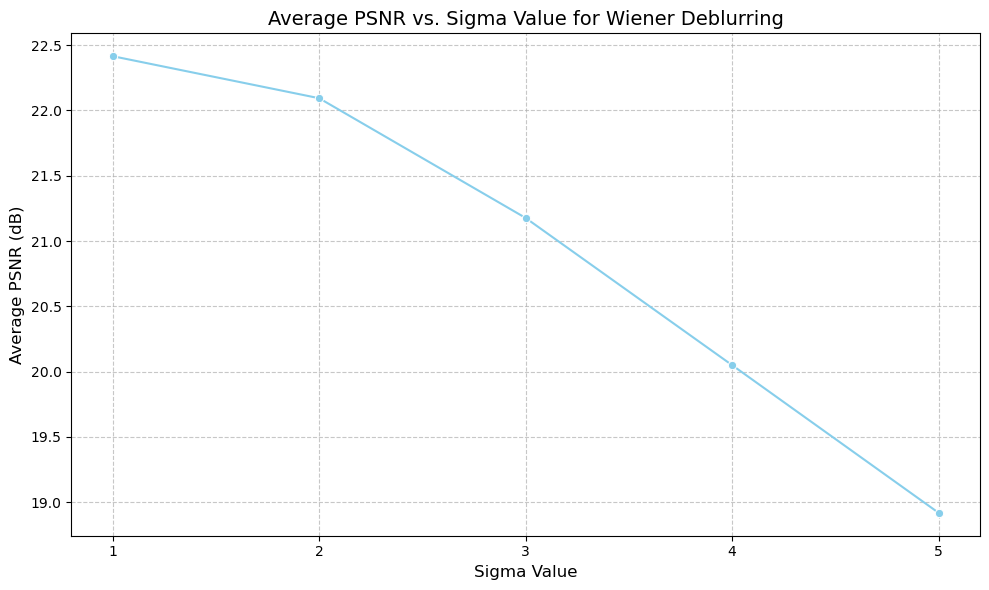

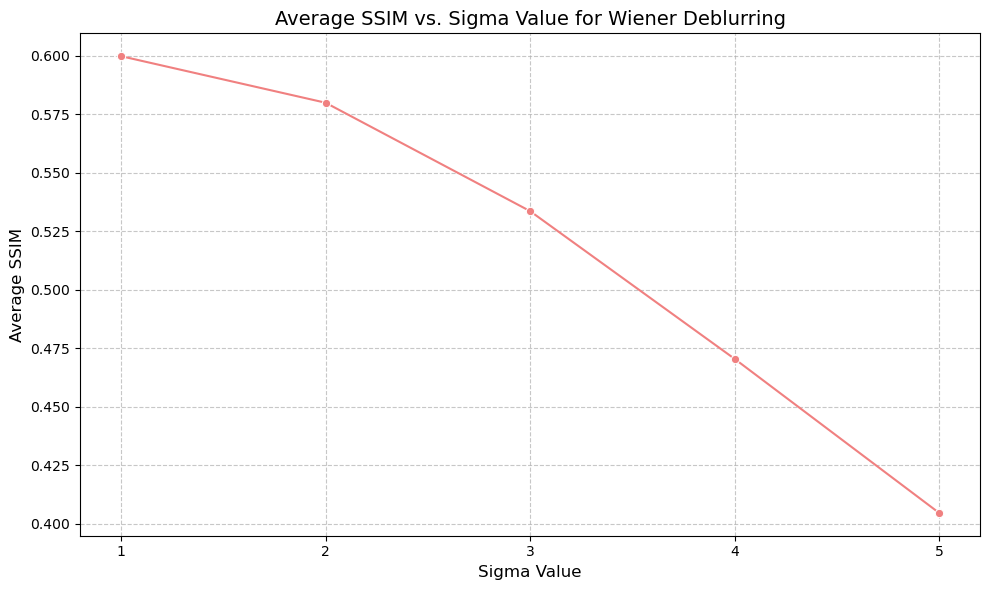

In [32]:
# Create a list of dataframes and their corresponding sigma values
dfs_and_sigmas = [
    (df_set_balanced_first, list_sigma[0]),
    (df_set_balanced_second, list_sigma[1]),
    (df_set_balanced_third, list_sigma[2]),
    (df_set_balanced_fourth, list_sigma[3]),
    (df_set_balanced_fith, list_sigma[4])
]

# Combine dataframes into a single dataframe for easier plotting
combined_metrics = pd.DataFrame()
for df, sigma_val in dfs_and_sigmas:
    df_copy = df.copy()
    df_copy['sigma'] = sigma_val
    combined_metrics = pd.concat([combined_metrics, df_copy], ignore_index=True)

# Calculate mean PSNR and SSIM for each sigma value
mean_metrics_by_sigma = combined_metrics.groupby('sigma')[['PSNR_deblur', 'SSIM_deblur']].mean().reset_index()

# Plotting PSNR vs. Sigma
plt.figure(figsize=(10, 6))
sns.lineplot(x='sigma', y='PSNR_deblur', data=mean_metrics_by_sigma, marker='o', color='skyblue')
plt.title('Average PSNR vs. Sigma Value for Wiener Deblurring', fontsize=14)
plt.xlabel('Sigma Value', fontsize=12)
plt.ylabel('Average PSNR (dB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(list_sigma)
plt.tight_layout()
plt.show()

# Plotting SSIM vs. Sigma
plt.figure(figsize=(10, 6))
sns.lineplot(x='sigma', y='SSIM_deblur', data=mean_metrics_by_sigma, marker='o', color='lightcoral')
plt.title('Average SSIM vs. Sigma Value for Wiener Deblurring', fontsize=14)
plt.xlabel('Sigma Value', fontsize=12)
plt.ylabel('Average SSIM', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(list_sigma)
plt.tight_layout()
plt.show()

In [13]:
set_sigma, list_balanced = 3, [0.05, 0.1, 0.15, 0.2, 0.3]

In [14]:
# script to run

start_time = time.perf_counter()
df_set_sigma_first = analyse_deblurring_metrics(BLUR_PATH, SHARP_PATH, size=15, power=set_sigma, balance=list_balanced[0])
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Total execution time: {elapsed_time/60:.2f} minutes.")

start_time = time.perf_counter()
df_set_sigma_second = analyse_deblurring_metrics(BLUR_PATH, SHARP_PATH, size=15, power=set_sigma, balance=list_balanced[1])
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Total execution time: {elapsed_time/60:.2f} minutes.")

start_time = time.perf_counter()
df_set_sigma_third = analyse_deblurring_metrics(BLUR_PATH, SHARP_PATH, size=15, power=set_sigma, balance=list_balanced[2])
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Total execution time: {elapsed_time/60:.2f} minutes.")

start_time = time.perf_counter()
df_set_sigma_fourth = analyse_deblurring_metrics(BLUR_PATH, SHARP_PATH, size=15, power=set_sigma, balance=list_balanced[3])
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Total execution time: {elapsed_time/60:.2f} minutes.")

start_time = time.perf_counter()
df_set_sigma_fifth = analyse_deblurring_metrics(BLUR_PATH, SHARP_PATH, size=15, power=set_sigma, balance=list_balanced[4])
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Total execution time: {elapsed_time/60:.2f} minutes.")

Analysing deblurring metrics for 5000 images...
Total execution time: 24.80 minutes.
Analysing deblurring metrics for 5000 images...
Total execution time: 23.97 minutes.
Analysing deblurring metrics for 5000 images...
Total execution time: 23.14 minutes.
Analysing deblurring metrics for 5000 images...
Total execution time: 23.40 minutes.
Analysing deblurring metrics for 5000 images...
Total execution time: 23.39 minutes.


In [15]:
print(df_set_sigma_first['PSNR_deblur'].mean())
print(df_set_sigma_second['PSNR_deblur'].mean())
print(df_set_sigma_third['PSNR_deblur'].mean())
print(df_set_sigma_fourth['PSNR_deblur'].mean())
print(df_set_sigma_fifth['PSNR_deblur'].mean())

20.321375449785947
20.89892722959772
21.17690496792401
21.34806288349519
21.5534500460474


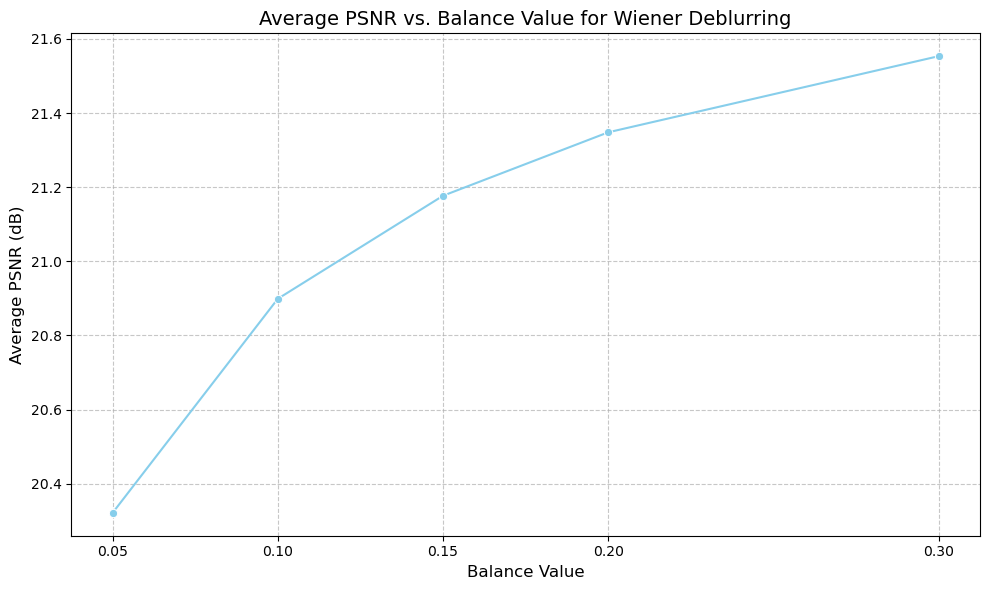

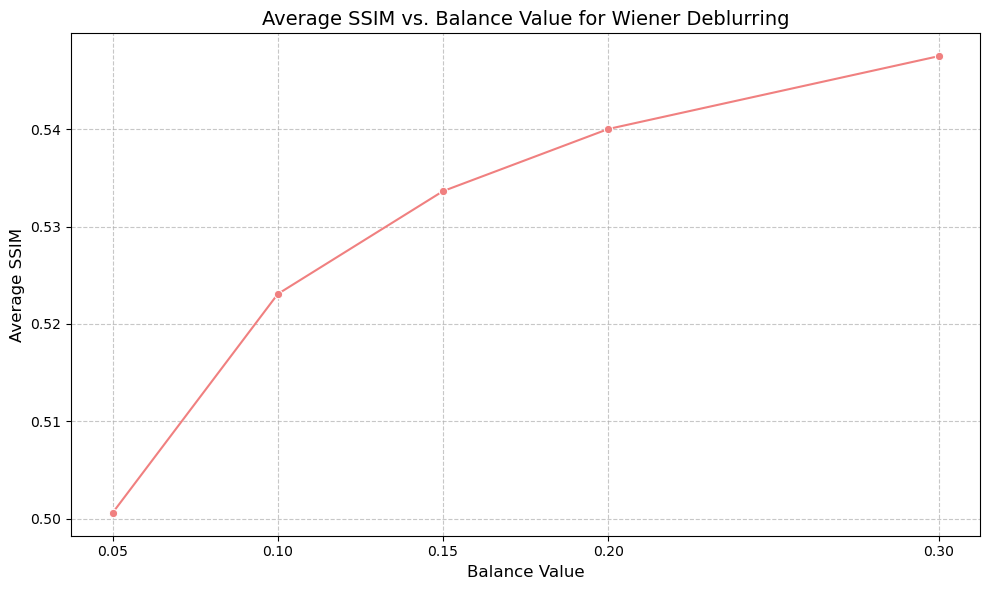

In [17]:
import seaborn as sns
# Create a list of dataframes 7and their corresponding balanced values
dfs_and_balanced = [
    (df_set_sigma_first, list_balanced[0]),
    (df_set_sigma_second, list_balanced[1]),
    (df_set_sigma_third, list_balanced[2]),
    (df_set_sigma_fourth, list_balanced[3]),
    (df_set_sigma_fifth, list_balanced[4])
]

# Combine dataframes into a single dataframe for easier plotting
combined_metrics = pd.DataFrame()
for df, balance_val in dfs_and_balanced:
    df_copy = df.copy()
    df_copy['balance'] = balance_val
    combined_metrics = pd.concat([combined_metrics, df_copy], ignore_index=True)

# Calculate mean PSNR and SSIM for each sigma value
mean_metrics_by_balance = combined_metrics.groupby('balance')[['PSNR_deblur', 'SSIM_deblur']].mean().reset_index()

# Plotting PSNR vs. Sigma
plt.figure(figsize=(10, 6))
sns.lineplot(x='balance', y='PSNR_deblur', data=mean_metrics_by_balance, marker='o', color='skyblue')
plt.title('Average PSNR vs. Balance Value for Wiener Deblurring', fontsize=14)
plt.xlabel('Balance Value', fontsize=12)
plt.ylabel('Average PSNR (dB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(list_balanced)
plt.tight_layout()
plt.show()

# Plotting SSIM vs. Sigma
plt.figure(figsize=(10, 6))
sns.lineplot(x='balance', y='SSIM_deblur', data=mean_metrics_by_balance, marker='o', color='lightcoral')
plt.title('Average SSIM vs. Balance Value for Wiener Deblurring', fontsize=14)
plt.xlabel('Balance Value', fontsize=12)
plt.ylabel('Average SSIM', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(list_balanced)
plt.tight_layout()
plt.show()